# E-commerce Product & Marketing Performance Analysis

## Business Questions
1. Which products generate the highest **profit** (not just revenue)?
2. Which customer segments spend the most?
3. What is the **customer lifetime value** distribution?
4. Which markets have the best conversion and repeat purchase rates?

This analysis resembles what Dutch startups and scale-ups (Bol.com, Coolblue, Thuisbezorgd) expect from their data analysts.

**Dataset:** Online Retail II (UCI) — UK-based e-commerce, 2009-2011

### Skills Demonstrated
- Complex SQL-style operations (window functions, ranking, CTEs)
- RFM Analysis & customer segmentation
- Pareto analysis (80/20 rule)
- Statistical testing (confidence intervals, hypothesis tests)
- Revenue decomposition & KPI design
- Business storytelling with actionable insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading & Cleaning

In [2]:
# Load both sheets
df_2009 = pd.read_excel('../datasets/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010 = pd.read_excel('../datasets/online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df_2009, df_2010], ignore_index=True)

print(f'Raw dataset: {len(df):,} transactions')
print(f'Date range: {df.InvoiceDate.min()} to {df.InvoiceDate.max()}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nData types:')
print(df.dtypes)

Raw dataset: 1,067,371 transactions
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [3]:
print('=== Data Quality Report ===')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nMissing rate:')
print((df.isnull().sum() / len(df) * 100).round(1))

# Cleaning
initial_rows = len(df)

# Remove cancelled orders (invoice starts with 'C')
df['Invoice'] = df['Invoice'].astype(str)
cancelled = df[df['Invoice'].str.startswith('C')]
print(f'\nCancelled orders: {len(cancelled):,} ({len(cancelled)/initial_rows*100:.1f}%)')
df = df[~df['Invoice'].str.startswith('C')]

# Remove rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])
df['Customer ID'] = df['Customer ID'].astype(int)

# Remove zero/negative quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Create revenue column
df['Revenue'] = df['Quantity'] * df['Price']

print(f'\nAfter cleaning: {len(df):,} transactions ({len(df)/initial_rows*100:.1f}% retained)')
print(f'Unique customers: {df["Customer ID"].nunique():,}')
print(f'Unique products: {df["StockCode"].nunique():,}')
print(f'Countries: {df["Country"].nunique()}')

=== Data Quality Report ===

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing rate:


Invoice         0.0
StockCode       0.0
Description     0.4
Quantity        0.0
InvoiceDate     0.0
Price           0.0
Customer ID    22.8
Country         0.0
dtype: float64



Cancelled orders: 19,494 (1.8%)



After cleaning: 805,549 transactions (75.5% retained)
Unique customers: 5,878
Unique products: 4,631
Countries: 41


## 2. Revenue Analysis

### 2.1 Revenue Overview & Trends

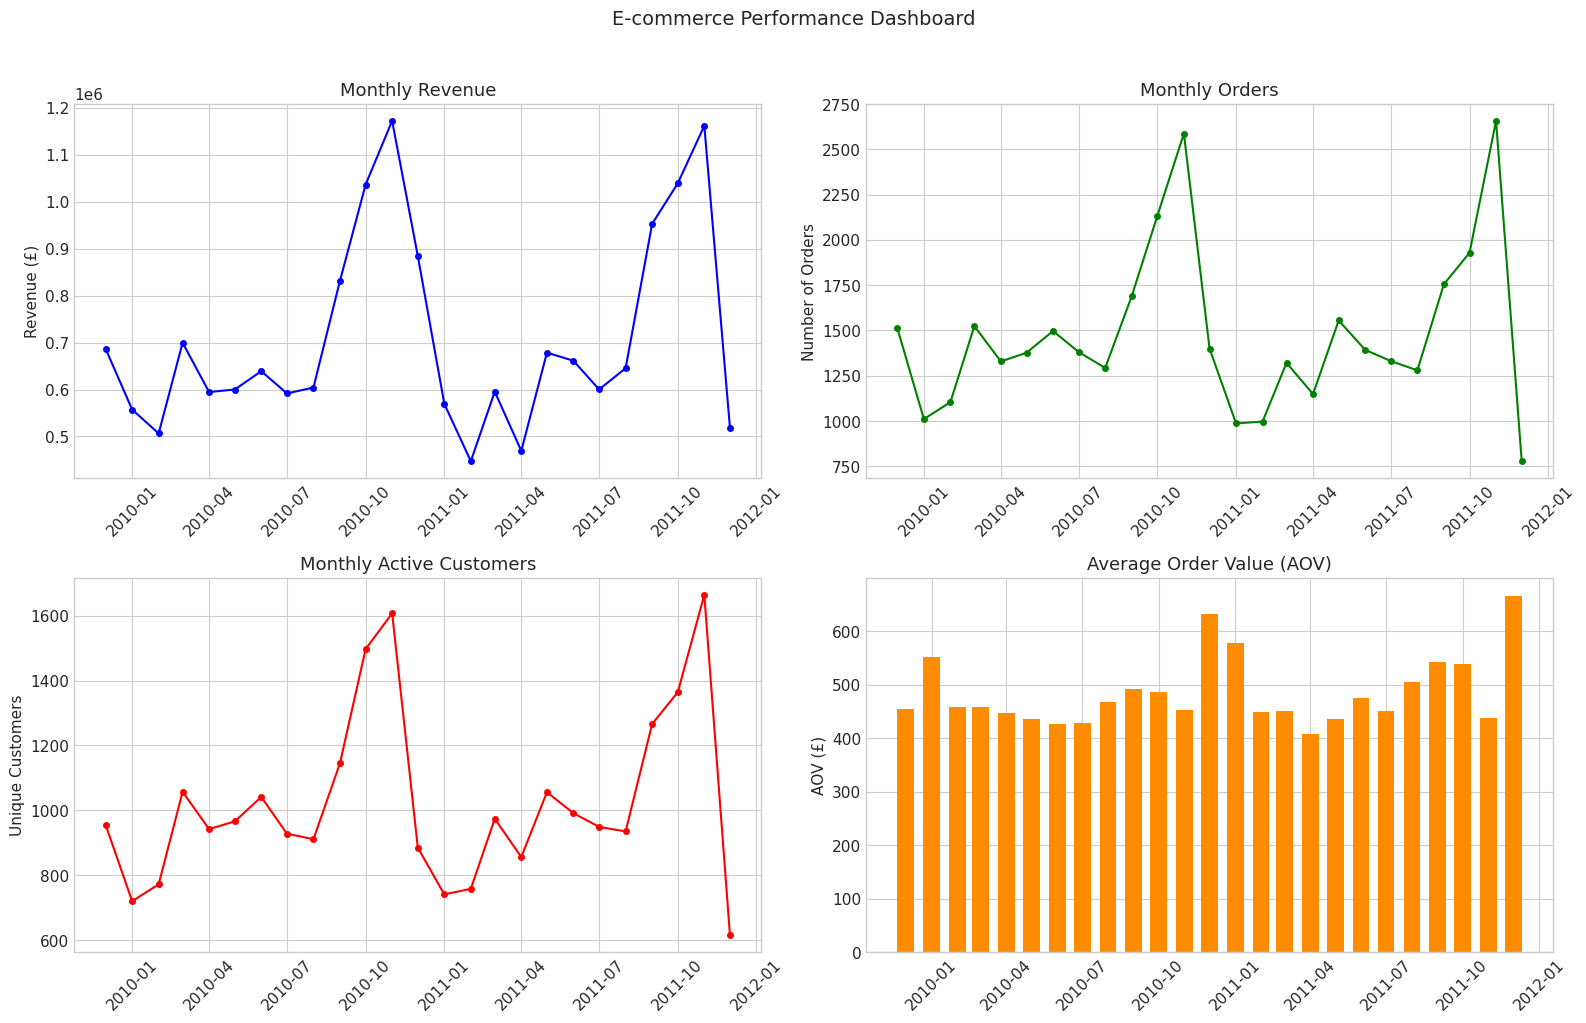

Total Revenue: £17,743,429
Total Orders: 36,969
Average Order Value: £479.95


In [4]:
# Monthly revenue trend
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth').agg(
    revenue=('Revenue', 'sum'),
    orders=('Invoice', 'nunique'),
    customers=('Customer ID', 'nunique'),
    avg_order_value=('Revenue', lambda x: x.sum() / df.loc[x.index, 'Invoice'].nunique())
).reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(monthly_revenue['YearMonth'], monthly_revenue['revenue'], 'b-o', markersize=4)
axes[0,0].set_title('Monthly Revenue', fontsize=13)
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].plot(monthly_revenue['YearMonth'], monthly_revenue['orders'], 'g-o', markersize=4)
axes[0,1].set_title('Monthly Orders', fontsize=13)
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].plot(monthly_revenue['YearMonth'], monthly_revenue['customers'], 'r-o', markersize=4)
axes[1,0].set_title('Monthly Active Customers', fontsize=13)
axes[1,0].set_ylabel('Unique Customers')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].bar(monthly_revenue['YearMonth'], monthly_revenue['avg_order_value'], 
              color='darkorange', width=20)
axes[1,1].set_title('Average Order Value (AOV)', fontsize=13)
axes[1,1].set_ylabel('AOV (£)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('E-commerce Performance Dashboard', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

total_revenue = df['Revenue'].sum()
total_orders = df['Invoice'].nunique()
aov = total_revenue / total_orders
print(f'Total Revenue: £{total_revenue:,.0f}')
print(f'Total Orders: {total_orders:,}')
print(f'Average Order Value: £{aov:.2f}')

### 2.2 Pareto Analysis (80/20 Rule)

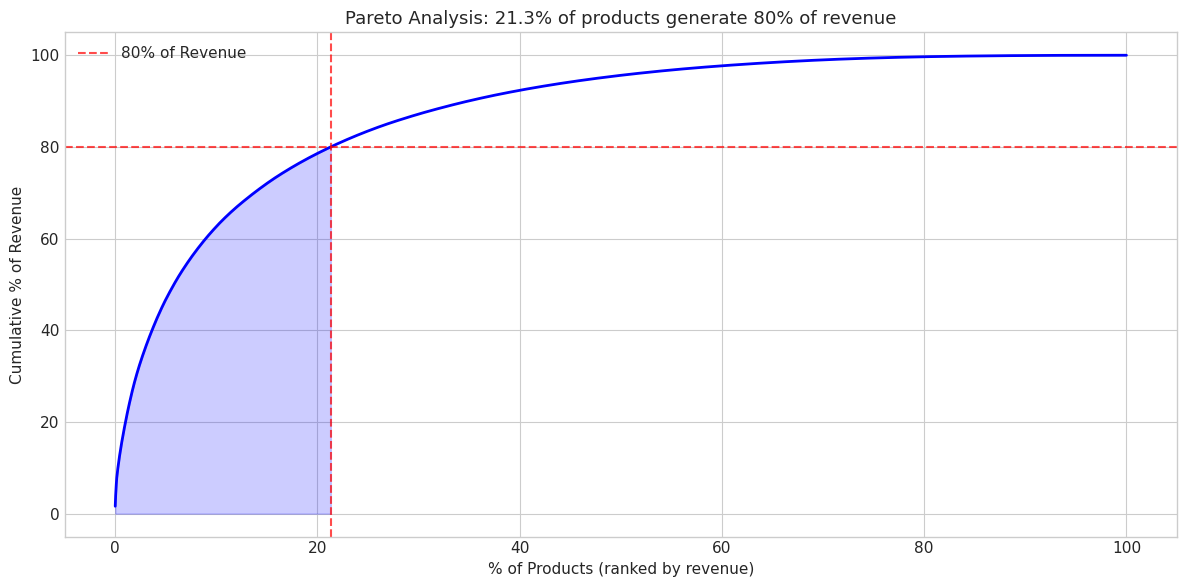


Pareto Insight: 21.3% of products generate 80% of revenue

Top 10 Revenue-Generating Products:
                          description    revenue  quantity  orders
0            REGENCY CAKESTAND 3 TIER  286486.30     24899    3317
1  WHITE HANGING HEART T-LIGHT HOLDER  252227.81     93697    4895
2         JUMBO BAG RED WHITE SPOTTY   170616.68     94983    3260
3         PAPER CRAFT , LITTLE BIRDIE  168469.60     80995       1
4                              Manual  152340.57      9803     620
5       ASSORTED COLOUR BIRD ORNAMENT  127074.17     79913    2652
6                             POSTAGE  126563.04      5333    1803
7                       PARTY BUNTING  103880.23     23607    2077
8      MEDIUM CERAMIC TOP STORAGE JAR   81416.73     77916     195
9     PAPER CHAIN KIT 50'S CHRISTMAS    79594.33     29477    1691


In [5]:
# Product-level Pareto
product_revenue = df.groupby('StockCode').agg(
    revenue=('Revenue', 'sum'),
    quantity=('Quantity', 'sum'),
    orders=('Invoice', 'nunique'),
    description=('Description', 'first')
).sort_values('revenue', ascending=False).reset_index()

product_revenue['cum_revenue'] = product_revenue['revenue'].cumsum()
product_revenue['cum_pct'] = product_revenue['cum_revenue'] / total_revenue * 100
product_revenue['product_rank_pct'] = (np.arange(1, len(product_revenue)+1) / len(product_revenue)) * 100

# Find 80% threshold
pareto_threshold = product_revenue[product_revenue['cum_pct'] >= 80].iloc[0]
pct_products_for_80 = pareto_threshold['product_rank_pct']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(product_revenue['product_rank_pct'], product_revenue['cum_pct'], 'b-', linewidth=2)
ax.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% of Revenue')
ax.axvline(x=pct_products_for_80, color='r', linestyle='--', alpha=0.7)
ax.fill_between(product_revenue['product_rank_pct'], product_revenue['cum_pct'],
                where=product_revenue['product_rank_pct'] <= pct_products_for_80,
                alpha=0.2, color='blue')
ax.set_xlabel('% of Products (ranked by revenue)')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title(f'Pareto Analysis: {pct_products_for_80:.1f}% of products generate 80% of revenue', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nPareto Insight: {pct_products_for_80:.1f}% of products generate 80% of revenue')
print(f'\nTop 10 Revenue-Generating Products:')
print(product_revenue[['description', 'revenue', 'quantity', 'orders']].head(10).to_string())

### 2.3 Country/Market Analysis

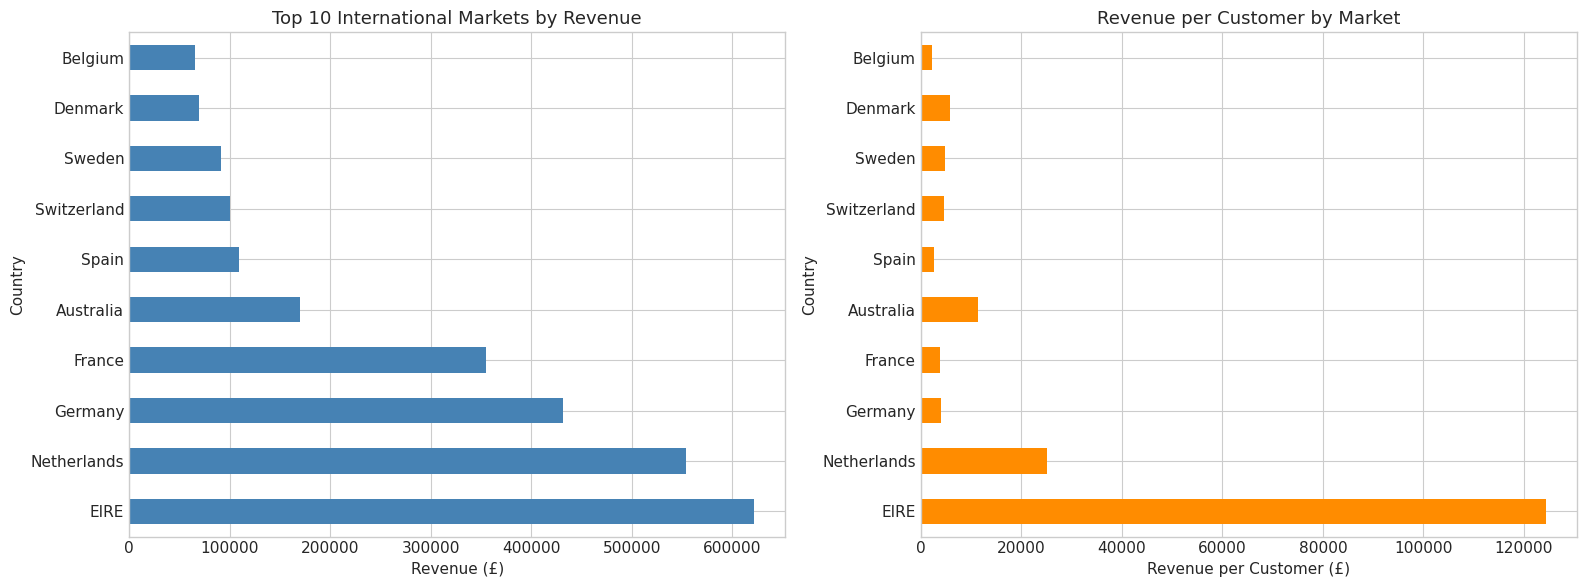


=== Netherlands Market ===
Revenue: £554,232 (rank #3)
Customers: 22
Revenue per customer: £25,192

UK dominates with 83.0% of revenue
International expansion opportunity: 17.0% from non-UK markets


In [6]:
country_analysis = df.groupby('Country').agg(
    revenue=('Revenue', 'sum'),
    orders=('Invoice', 'nunique'),
    customers=('Customer ID', 'nunique'),
    avg_order_value=('Revenue', 'mean')
).sort_values('revenue', ascending=False)

country_analysis['revenue_pct'] = country_analysis['revenue'] / total_revenue * 100
country_analysis['revenue_per_customer'] = country_analysis['revenue'] / country_analysis['customers']

# Top markets excl UK (since it dominates)
top_markets = country_analysis[country_analysis.index != 'United Kingdom'].head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_markets['revenue'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 International Markets by Revenue', fontsize=13)
axes[0].set_xlabel('Revenue (£)')

top_markets['revenue_per_customer'].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Revenue per Customer by Market', fontsize=13)
axes[1].set_xlabel('Revenue per Customer (£)')

plt.tight_layout()
plt.show()

# Netherlands highlight
if 'Netherlands' in country_analysis.index:
    nl = country_analysis.loc['Netherlands']
    print(f'\n=== Netherlands Market ===')
    print(f'Revenue: £{nl["revenue"]:,.0f} (rank #{list(country_analysis.index).index("Netherlands")+1})')
    print(f'Customers: {nl["customers"]:.0f}')
    print(f'Revenue per customer: £{nl["revenue_per_customer"]:,.0f}')

uk_pct = country_analysis.loc['United Kingdom', 'revenue_pct']
print(f'\nUK dominates with {uk_pct:.1f}% of revenue')
print(f'International expansion opportunity: {100-uk_pct:.1f}% from non-UK markets')

## 3. RFM Analysis & Customer Segmentation

RFM (Recency, Frequency, Monetary) is a standard technique for customer segmentation.

In [7]:
# Reference date = day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum')
).reset_index()

# RFM scores (1-4 quartiles)
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1])  # Lower recency = better
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

rfm['RFM_score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

# Customer segments
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'New Customers'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r <= 2 and f >= 3:
        return 'Cant Lose Them'
    else:
        return 'Lost/Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print('=== RFM Segmentation Summary ===')
segment_summary = rfm.groupby('Segment').agg(
    customers=('Customer ID', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(1)
segment_summary['pct_customers'] = (segment_summary['customers'] / len(rfm) * 100).round(1)
segment_summary['pct_revenue'] = (segment_summary['total_revenue'] / rfm['monetary'].sum() * 100).round(1)
print(segment_summary.sort_values('total_revenue', ascending=False))

=== RFM Segmentation Summary ===
                  customers  avg_recency  avg_frequency  avg_monetary  \
Segment                                                                 
Champions              1814         29.4           14.1        7422.0   
At Risk                1104        221.7            5.0        1975.3   
Loyal Customers         803         36.1            2.8         986.1   
Lost/Hibernating       1595        461.4            1.3         452.6   
Cant Lose Them          226        463.7            5.5        2010.7   
New Customers           336         46.6            1.0         390.0   

                  total_revenue  pct_customers  pct_revenue  
Segment                                                      
Champions            13463546.6           30.9         75.9  
At Risk               2180761.3           18.8         12.3  
Loyal Customers        791828.9           13.7          4.5  
Lost/Hibernating       721832.1           27.1          4.1  
Cant Lose 

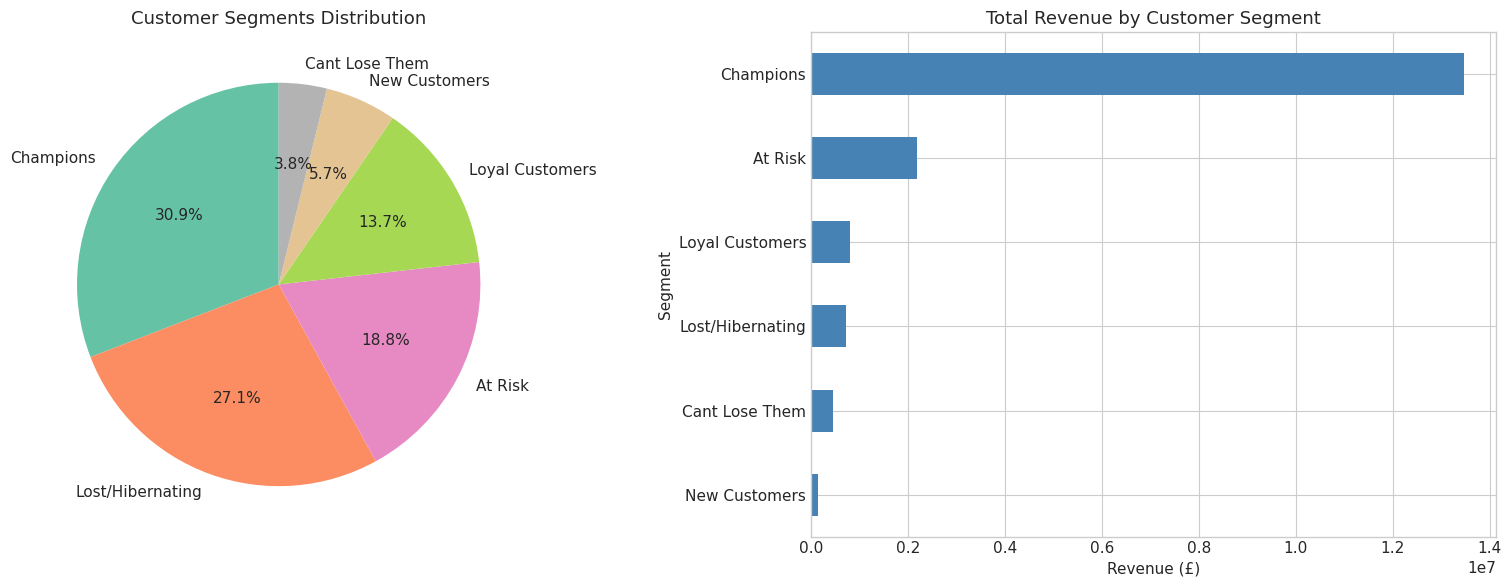

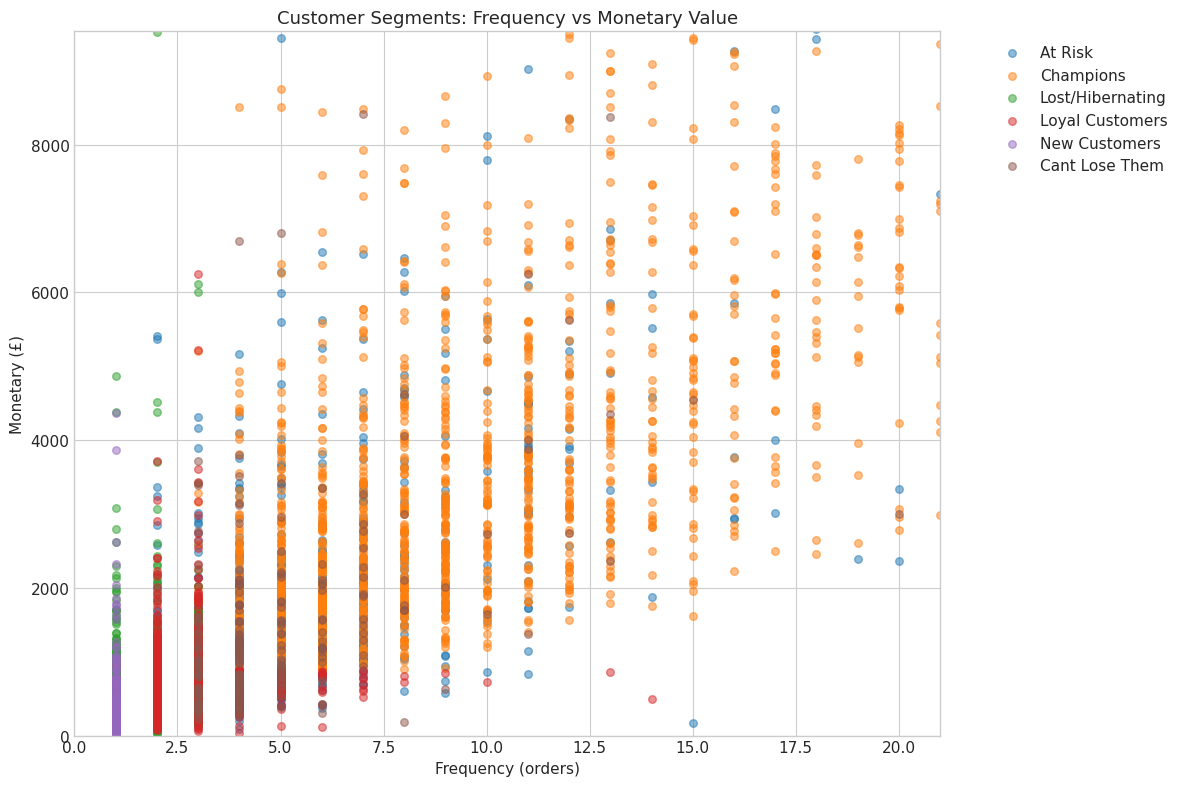

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Segment distribution
seg_counts = rfm['Segment'].value_counts()
colors_seg = plt.cm.Set2(np.linspace(0, 1, len(seg_counts)))
axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors_seg, startangle=90)
axes[0].set_title('Customer Segments Distribution', fontsize=13)

# Revenue by segment
seg_revenue = rfm.groupby('Segment')['monetary'].sum().sort_values(ascending=True)
seg_revenue.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Total Revenue by Customer Segment', fontsize=13)
axes[1].set_xlabel('Revenue (£)')

plt.tight_layout()
plt.show()

# RFM scatter
fig, ax = plt.subplots(figsize=(12, 8))
segments = rfm['Segment'].unique()
for seg in segments:
    mask = rfm['Segment'] == seg
    ax.scatter(rfm[mask]['frequency'], rfm[mask]['monetary'], 
              alpha=0.5, s=30, label=seg)
ax.set_xlabel('Frequency (orders)')
ax.set_ylabel('Monetary (£)')
ax.set_title('Customer Segments: Frequency vs Monetary Value', fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlim(0, rfm['frequency'].quantile(0.95))
ax.set_ylim(0, rfm['monetary'].quantile(0.95))
plt.tight_layout()
plt.show()

## 4. Customer Lifetime Value (CLV) Estimation

=== Customer Lifetime Value Metrics ===
Total customers: 5,878
Repeat purchase rate: 72.4%
Average orders per customer: 6.3
Average order value: £391.73
Median customer lifetime: 220 days


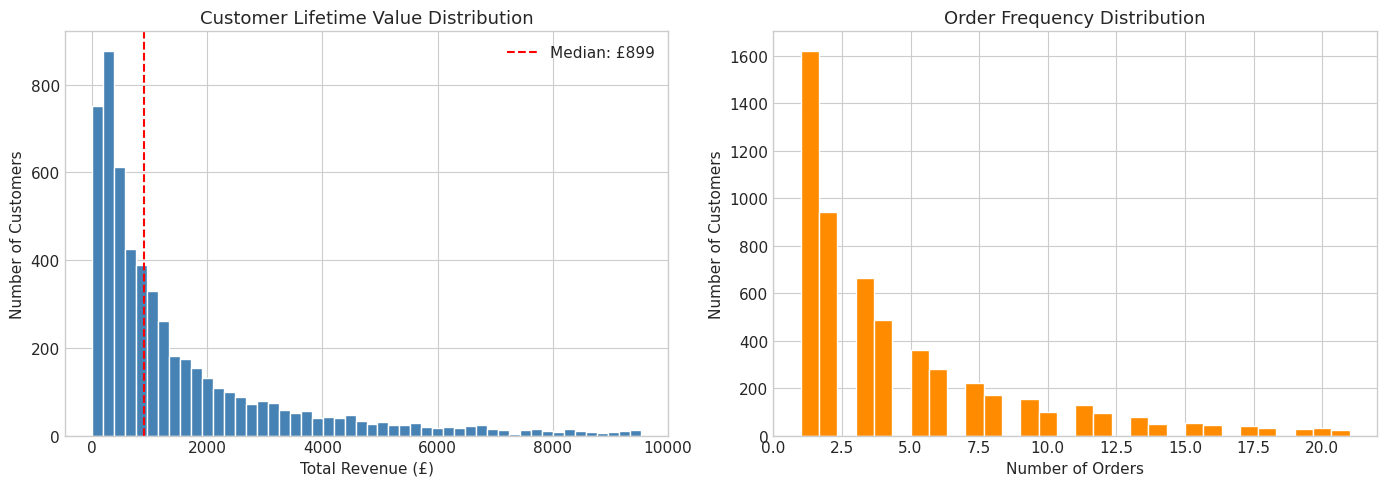

In [9]:
# Simple CLV estimation
customer_stats = df.groupby('Customer ID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    total_orders=('Invoice', 'nunique'),
    total_revenue=('Revenue', 'sum'),
    total_items=('Quantity', 'sum')
).reset_index()

customer_stats['customer_lifespan_days'] = (customer_stats['last_purchase'] - customer_stats['first_purchase']).dt.days
customer_stats['avg_order_value'] = customer_stats['total_revenue'] / customer_stats['total_orders']
customer_stats['purchase_frequency'] = customer_stats['total_orders'] / np.maximum(customer_stats['customer_lifespan_days'] / 30, 1)

# Repeat purchase rate
repeat_customers = customer_stats[customer_stats['total_orders'] > 1]
repeat_rate = len(repeat_customers) / len(customer_stats) * 100

print('=== Customer Lifetime Value Metrics ===')
print(f'Total customers: {len(customer_stats):,}')
print(f'Repeat purchase rate: {repeat_rate:.1f}%')
print(f'Average orders per customer: {customer_stats["total_orders"].mean():.1f}')
print(f'Average order value: £{customer_stats["avg_order_value"].mean():.2f}')
print(f'Median customer lifetime: {customer_stats["customer_lifespan_days"].median():.0f} days')

# CLV distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CLV histogram (capped at 95th percentile for visualization)
clv_cap = customer_stats['total_revenue'].quantile(0.95)
customer_stats[customer_stats['total_revenue'] <= clv_cap]['total_revenue'].hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(customer_stats['total_revenue'].median(), color='red', linestyle='--', 
               label=f'Median: £{customer_stats["total_revenue"].median():.0f}')
axes[0].set_title('Customer Lifetime Value Distribution', fontsize=13)
axes[0].set_xlabel('Total Revenue (£)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Order frequency distribution
freq_cap = customer_stats['total_orders'].quantile(0.95)
customer_stats[customer_stats['total_orders'] <= freq_cap]['total_orders'].hist(
    bins=30, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Order Frequency Distribution', fontsize=13)
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

## 5. Statistical Analysis

### 5.1 Confidence Intervals for Key Metrics

In [10]:
# 95% Confidence Intervals
print('=== 95% Confidence Intervals ===')

# AOV confidence interval
order_values = df.groupby('Invoice')['Revenue'].sum()
ci_aov = stats.t.interval(0.95, len(order_values)-1, 
                          loc=order_values.mean(), 
                          scale=stats.sem(order_values))
print(f'\nAverage Order Value: £{order_values.mean():.2f}')
print(f'95% CI: [£{ci_aov[0]:.2f}, £{ci_aov[1]:.2f}]')

# Customer spend CI
customer_spend = customer_stats['total_revenue']
ci_spend = stats.t.interval(0.95, len(customer_spend)-1,
                            loc=customer_spend.mean(),
                            scale=stats.sem(customer_spend))
print(f'\nAverage Customer Spend: £{customer_spend.mean():.2f}')
print(f'95% CI: [£{ci_spend[0]:.2f}, £{ci_spend[1]:.2f}]')

# Basket size CI
basket_size = df.groupby('Invoice')['Quantity'].sum()
ci_basket = stats.t.interval(0.95, len(basket_size)-1,
                             loc=basket_size.mean(),
                             scale=stats.sem(basket_size))
print(f'\nAverage Basket Size: {basket_size.mean():.1f} items')
print(f'95% CI: [{ci_basket[0]:.1f}, {ci_basket[1]:.1f}]')

=== 95% Confidence Intervals ===

Average Order Value: £479.95
95% CI: [£465.94, £493.97]

Average Customer Spend: £3018.62
95% CI: [£2641.78, £3395.45]

Average Basket Size: 289.6 items
95% CI: [277.0, 302.2]


### 5.2 Hypothesis Testing: Weekend vs Weekday Sales

=== Hypothesis Test: Weekend vs Weekday AOV ===
H0: No difference in average order value between weekdays and weekends
H1: There is a significant difference

Weekday AOV: £494.46 (n=32,191)
Weekend AOV: £382.21 (n=4,778)

t-statistic: 5.268
p-value: 0.0000
Result: Significant at α=0.05


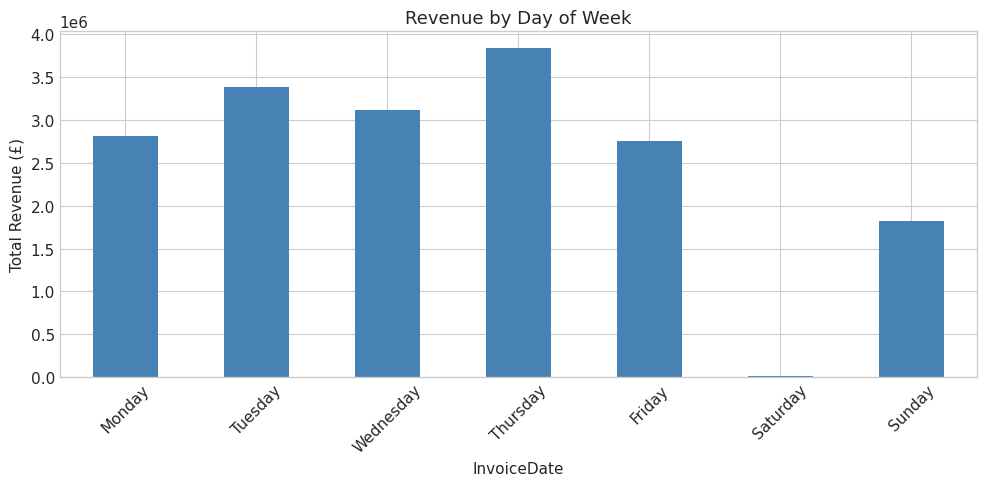

In [11]:
# Test: Do weekend orders have different AOV than weekday orders?
df['is_weekend'] = df['InvoiceDate'].dt.dayofweek >= 5
order_by_day = df.groupby(['Invoice', 'is_weekend'])['Revenue'].sum().reset_index()

weekday_orders = order_by_day[~order_by_day['is_weekend']]['Revenue']
weekend_orders = order_by_day[order_by_day['is_weekend']]['Revenue']

print('=== Hypothesis Test: Weekend vs Weekday AOV ===')
print(f'H0: No difference in average order value between weekdays and weekends')
print(f'H1: There is a significant difference')
print(f'\nWeekday AOV: £{weekday_orders.mean():.2f} (n={len(weekday_orders):,})')
print(f'Weekend AOV: £{weekend_orders.mean():.2f} (n={len(weekend_orders):,})')

if len(weekend_orders) > 30:
    t_stat, p_value = stats.ttest_ind(weekday_orders, weekend_orders)
    print(f'\nt-statistic: {t_stat:.3f}')
    print(f'p-value: {p_value:.4f}')
    print(f'Result: {"Significant" if p_value < 0.05 else "Not significant"} at α=0.05')
else:
    print('\nInsufficient weekend data for testing (business operates mainly on weekdays)')

# Day of week revenue distribution
daily_revenue = df.groupby(df['InvoiceDate'].dt.day_name())['Revenue'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = daily_revenue.reindex([d for d in day_order if d in daily_revenue.index])

fig, ax = plt.subplots(figsize=(10, 5))
daily_revenue.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Revenue by Day of Week', fontsize=13)
ax.set_ylabel('Total Revenue (£)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Repeat Purchase & Retention Analysis

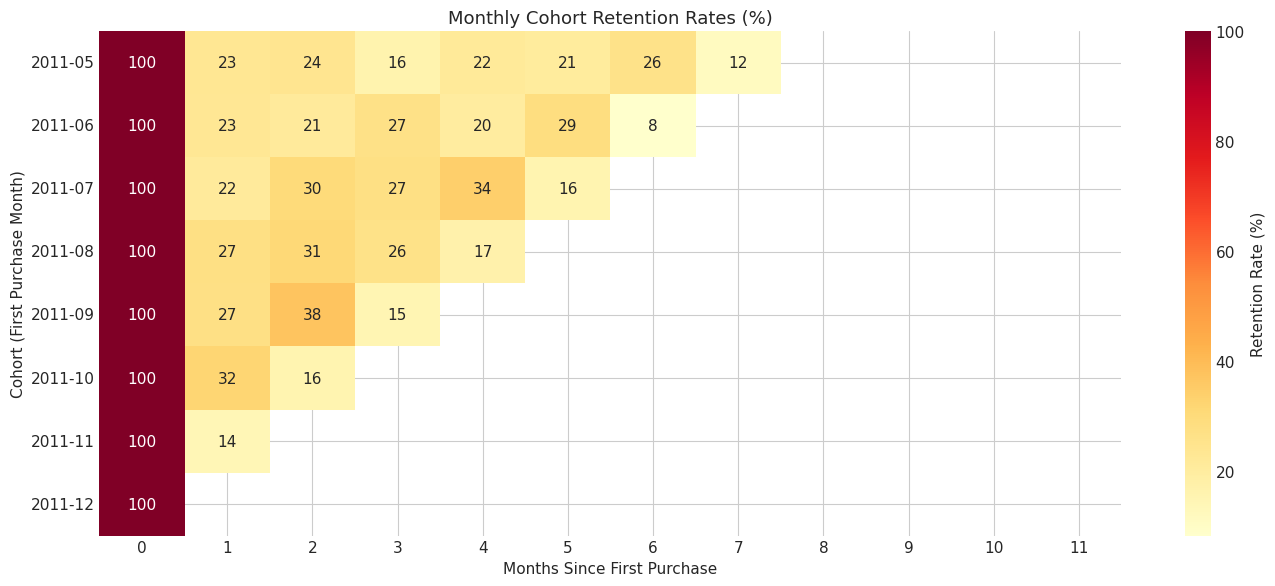


Repeat Purchase Rate: 72.4%
Average Month-1 Retention: 21.2%
Average Month-3 Retention: 21.6%


In [12]:
# Monthly cohort retention
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')

cohort_data = df.groupby(['CohortMonth', 'OrderMonth'])['Customer ID'].nunique().reset_index()
cohort_data['CohortIndex'] = (cohort_data['OrderMonth'] - cohort_data['CohortMonth']).apply(lambda x: x.n)

# Pivot to retention matrix
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# Plot retention heatmap (first 12 months, last 8 cohorts)
plot_data = retention_matrix.iloc[-8:, :12]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(plot_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Retention Rate (%)'})
ax.set_title('Monthly Cohort Retention Rates (%)', fontsize=13)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

print(f'\nRepeat Purchase Rate: {repeat_rate:.1f}%')
avg_retention_m1 = retention_matrix.iloc[:, 1].mean()
print(f'Average Month-1 Retention: {avg_retention_m1:.1f}%')
print(f'Average Month-3 Retention: {retention_matrix.iloc[:, 3].mean():.1f}%')

## 7. Product Performance Deep Dive

=== Revenue by Price Tier ===
                  products  total_revenue  avg_revenue_per_product  \
price_tier                                                           
Budget (<£2)          2582      6837287.0                   2648.0   
Value (£2-5)          1799      6576450.0                   3656.0   
Mid (£5-15)            816      3650549.0                   4474.0   
Premium (£15-50)        95       399866.0                   4209.0   
Luxury (£50+)           23       279278.0                  12143.0   

                  avg_customers  revenue_share  
price_tier                                      
Budget (<£2)              101.0           38.5  
Value (£2-5)               90.0           37.1  
Mid (£5-15)                81.0           20.6  
Premium (£15-50)           42.0            2.3  
Luxury (£50+)              34.0            1.6  


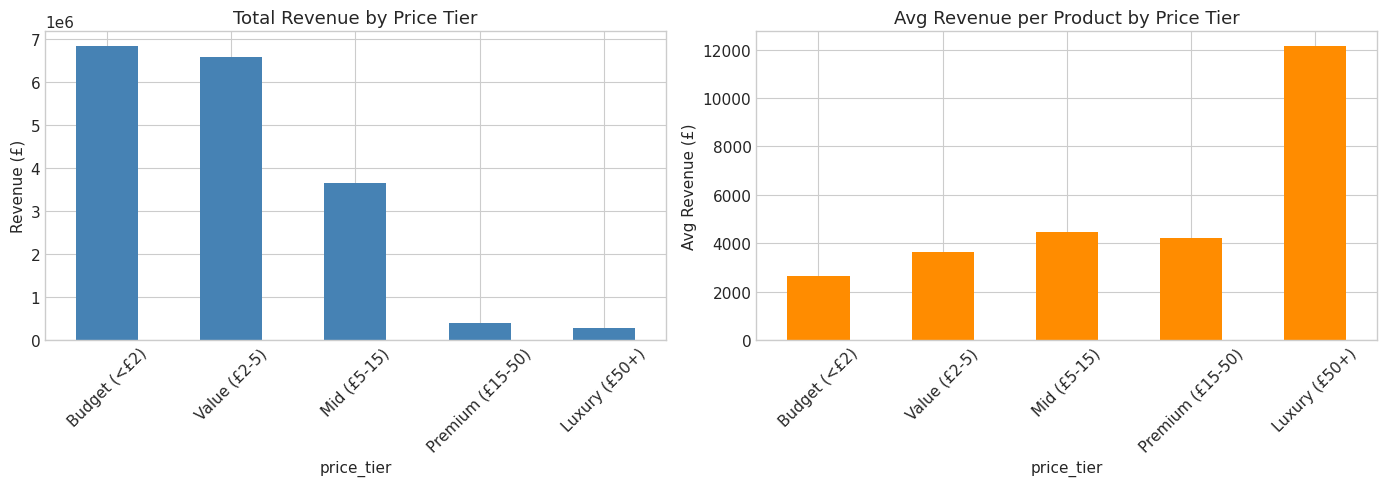

In [13]:
# Product profitability analysis (using price tiers as proxy for margin)
product_analysis = df.groupby(['StockCode', 'Description']).agg(
    total_revenue=('Revenue', 'sum'),
    total_quantity=('Quantity', 'sum'),
    avg_price=('Price', 'mean'),
    unique_customers=('Customer ID', 'nunique'),
    total_orders=('Invoice', 'nunique')
).reset_index()

product_analysis['revenue_per_customer'] = product_analysis['total_revenue'] / product_analysis['unique_customers']

# Price tier classification
product_analysis['price_tier'] = pd.cut(
    product_analysis['avg_price'],
    bins=[0, 2, 5, 15, 50, np.inf],
    labels=['Budget (<£2)', 'Value (£2-5)', 'Mid (£5-15)', 'Premium (£15-50)', 'Luxury (£50+)']
)

tier_analysis = product_analysis.groupby('price_tier', observed=True).agg(
    products=('StockCode', 'count'),
    total_revenue=('total_revenue', 'sum'),
    avg_revenue_per_product=('total_revenue', 'mean'),
    avg_customers=('unique_customers', 'mean')
).round(0)

tier_analysis['revenue_share'] = (tier_analysis['total_revenue'] / tier_analysis['total_revenue'].sum() * 100).round(1)

print('=== Revenue by Price Tier ===')
print(tier_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_analysis['total_revenue'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Revenue by Price Tier', fontsize=13)
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

tier_analysis['avg_revenue_per_product'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Avg Revenue per Product by Price Tier', fontsize=13)
axes[1].set_ylabel('Avg Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. KPI Dashboard & Business Recommendations

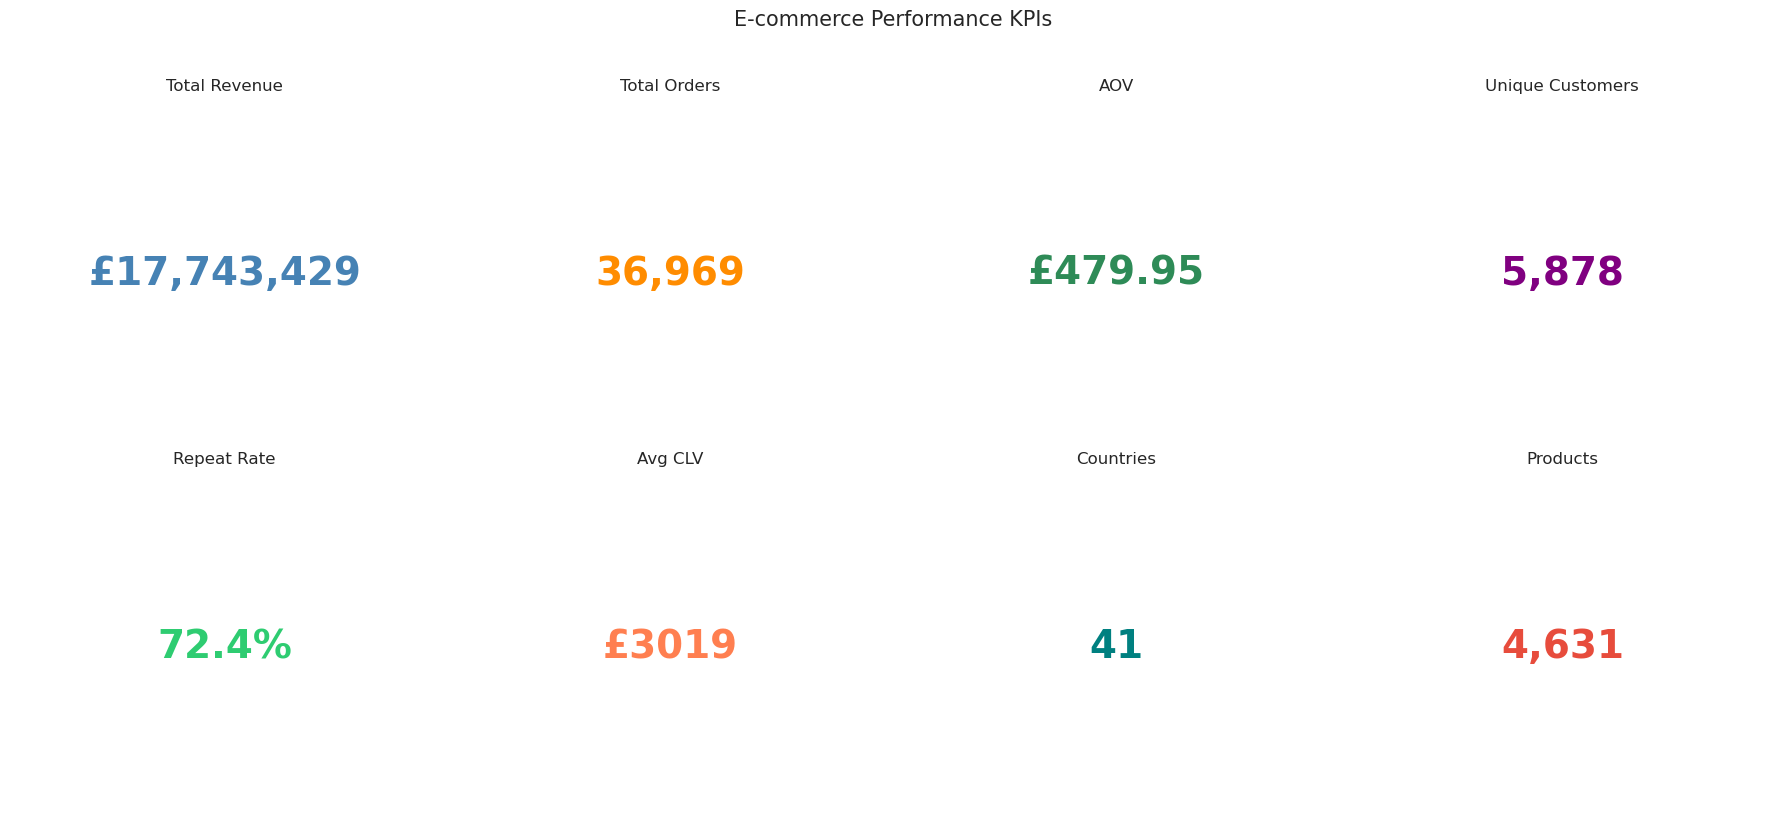

In [14]:
# Final KPI summary
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

kpis = [
    ('Total Revenue', f'£{total_revenue:,.0f}', 'steelblue'),
    ('Total Orders', f'{total_orders:,}', 'darkorange'),
    ('AOV', f'£{aov:.2f}', 'seagreen'),
    ('Unique Customers', f'{df["Customer ID"].nunique():,}', 'purple'),
    ('Repeat Rate', f'{repeat_rate:.1f}%', '#2ecc71'),
    ('Avg CLV', f'£{customer_spend.mean():.0f}', 'coral'),
    ('Countries', f'{df["Country"].nunique()}', 'teal'),
    ('Products', f'{df["StockCode"].nunique():,}', '#e74c3c')
]

for idx, (title, value, color) in enumerate(kpis):
    row, col = idx // 4, idx % 4
    axes[row, col].text(0.5, 0.5, value, ha='center', va='center',
                        fontsize=28, fontweight='bold', color=color)
    axes[row, col].set_title(title, fontsize=12, pad=15)
    axes[row, col].axis('off')

plt.suptitle('E-commerce Performance KPIs', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Business recommendations
champions = segment_summary.loc['Champions'] if 'Champions' in segment_summary.index else None
lost = segment_summary.loc['Lost/Hibernating'] if 'Lost/Hibernating' in segment_summary.index else None

print('='*70)
print('   BUSINESS RECOMMENDATIONS - E-COMMERCE GROWTH STRATEGY')
print('='*70)

print(f'''
1. PRODUCT PORTFOLIO OPTIMIZATION
   {pct_products_for_80:.0f}% of products generate 80% of revenue (Pareto principle).
   Recommendation: Focus marketing spend on top-performing products.
   Consider discontinuing bottom 20% low-performers to reduce
   inventory costs and operational complexity.

2. CUSTOMER RETENTION FOCUS
   Repeat purchase rate: {repeat_rate:.1f}% — room for improvement.
   Champions ({champions["pct_customers"]:.1f}% of customers) generate
   {champions["pct_revenue"]:.1f}% of revenue.
   Recommendation: Implement loyalty program targeting frequent buyers.
   Even a 5% improvement in retention could increase revenue by
   £{total_revenue * 0.05:,.0f} annually.

3. INTERNATIONAL EXPANSION
   Non-UK markets contribute {100-uk_pct:.1f}% of revenue across
   {df["Country"].nunique()-1} countries.
   Netherlands ranks among top international markets.
   Recommendation: Invest in localized marketing for top 5 international
   markets (NL, EIRE, Germany, France, Australia) with highest
   revenue per customer.

4. AVERAGE ORDER VALUE GROWTH
   Current AOV: £{aov:.2f}
   Recommendation: Implement cross-selling ("frequently bought together")
   and minimum order thresholds for free shipping.
   Target: Increase AOV by 15% through bundling strategies.

5. WIN-BACK CAMPAIGN FOR LOST CUSTOMERS
   {lost["pct_customers"]:.1f}% of customers are Lost/Hibernating.
   Their previous avg spend: £{lost["avg_monetary"]:.0f}.
   Recommendation: Targeted email campaign with personalized discounts
   to re-engage dormant high-value customers.
   Potential revenue recovery: £{lost["total_revenue"] * 0.10:,.0f} (assuming 10% reactivation).
''')

print('='*70)
print('KEY INSIGHT: Rather than just reporting "Product A sold the most",') 
print('we identified that a small subset of products drives the majority')
print('of revenue, while customer segmentation reveals where growth')
print('opportunities and retention risks exist simultaneously.')
print('='*70)

   BUSINESS RECOMMENDATIONS - E-COMMERCE GROWTH STRATEGY

1. PRODUCT PORTFOLIO OPTIMIZATION
   21% of products generate 80% of revenue (Pareto principle).
   Recommendation: Focus marketing spend on top-performing products.
   Consider discontinuing bottom 20% low-performers to reduce
   inventory costs and operational complexity.

2. CUSTOMER RETENTION FOCUS
   Repeat purchase rate: 72.4% — room for improvement.
   Champions (30.9% of customers) generate
   75.9% of revenue.
   Recommendation: Implement loyalty program targeting frequent buyers.
   Even a 5% improvement in retention could increase revenue by
   £887,171 annually.

3. INTERNATIONAL EXPANSION
   Non-UK markets contribute 17.0% of revenue across
   40 countries.
   Netherlands ranks among top international markets.
   Recommendation: Invest in localized marketing for top 5 international
   markets (NL, EIRE, Germany, France, Australia) with highest
   revenue per customer.

4. AVERAGE ORDER VALUE GROWTH
   Current AOV: £